# PHASE 3: Further Exploratory Data Analysis (EDA) 
**Traceability**
- Issue ID: #3 Exploratory Data Analysis

## 1. Objectives
- Load raw data.
- Analyze data properties.
- Perform initial cleaning (remove zero-variance features).
- Output the `cleaned_dataset.csv` for experimentation.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# ── Plotting Config ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
COLORS = ['#1F4E79', '#2E75B6', '#70AD47', '#FF7043', '#AB47BC']

# ── Global Config ────────────────────────────────────────────────────────
DATA_DIR = Path('../data')
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Column Definitions
INDEX_COLS = ['unit_number', 'time_cycles']
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']
SENSOR_COLS = [f's_{i}' for i in range(1, 22)]
COL_NAMES = INDEX_COLS + SETTING_COLS + SENSOR_COLS

# Load Processed Data
print("⏳ Loading processed datasets...")
try:
    df_train = pd.read_csv(PROCESSED_DIR / 'train_cleaned.csv')
    df_valid = pd.read_csv(PROCESSED_DIR / 'valid_cleaned.csv')
    
    # Identify sensor columns
    SENSOR_COLS = [c for c in df_train.columns if c.startswith('s_')]
    sensor_cols = SENSOR_COLS.copy()  # Keep lowercase alias used in downstream cells
    INDEX_COLS = ['unit_number', 'time_cycles']
    
    print(f"✅ Processed data loaded. Train: {df_train.shape}, Test: {df_valid.shape}")
except FileNotFoundError:
    print("❌ Processed files not found. Ensure 'train_cleaned.csv' and 'test_cleaned.csv' exist.")
    raise

⏳ Loading processed datasets...
✅ Processed data loaded. Train: (20631, 20), Test: (13096, 20)


In [2]:
df_train.head()

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,RUL
0,1.0,1.0,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392.0,39.06,23.4190,191.0
1,1.0,2.0,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392.0,39.00,23.4236,190.0
2,1.0,3.0,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390.0,38.95,23.3442,189.0
3,1.0,4.0,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392.0,38.88,23.3739,188.0
4,1.0,5.0,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393.0,38.90,23.4044,187.0


### Diagnostic: Engine Lifetime Analysis
We need to know how long engines typically last to define "Early", "Mid", and "Late" life stages.

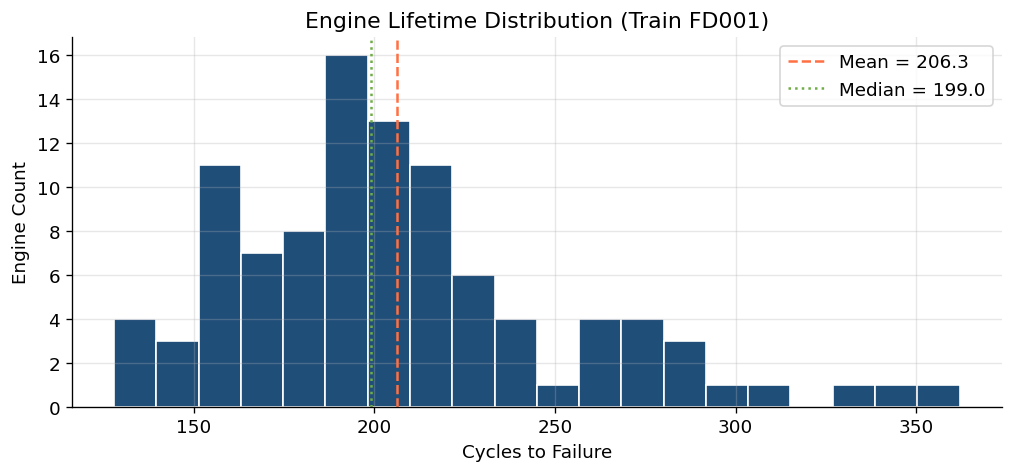

--- Engine Lifetime Stats ---
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_cycles, dtype: float64


In [3]:
def engine_lifetime_analysis(df):
    """Plot distribution of engine lifetimes."""
    max_cycles = df.groupby('unit_number')['time_cycles'].max()
    
    plt.figure(figsize=(10, 4))
    plt.hist(max_cycles, bins=20, color=COLORS[0], edgecolor='white')
    plt.axvline(max_cycles.mean(), color=COLORS[3], linestyle='--', label=f'Mean = {max_cycles.mean():.1f}')
    plt.axvline(max_cycles.median(), color=COLORS[2], linestyle=':', label=f'Median = {max_cycles.median():.1f}')
    plt.title('Engine Lifetime Distribution (Train FD001)')
    plt.xlabel('Cycles to Failure')
    plt.ylabel('Engine Count')
    plt.legend()
    plt.show()
    
    return max_cycles.describe()

lifetime_stats = engine_lifetime_analysis(df_train)
print("--- Engine Lifetime Stats ---")
print(lifetime_stats)

### Graph Analysis: Engine Lifetime Distribution

- The distribution is right-skewed: most engines fail around ~170–230 cycles, but a smaller group survives much longer (up to ~360 cycles).
- Mean lifetime (**206.3**) is higher than median (**199.0**), confirming the right tail from long-lived engines.
- This spread indicates meaningful unit-to-unit heterogeneity; a single global degradation pace assumption is likely too simplistic.
- The dense central region suggests many engines follow a common lifecycle, while tail engines may represent different operating conditions or initial health states.
- Modeling implication: avoid hard stage cutoffs based only on fixed cycle numbers; prefer RUL-relative features and per-unit temporal dynamics.
- Validation implication: preserve distribution shape across splits so the long-lifetime tail is represented in train/validation sets.

#### Suggested Actions
1. **Use piecewise-linear (clipped) RUL target** — clip RUL at 125 cycles so the model focuses on the degradation region rather than wasting capacity on the flat healthy plateau.
2. **Keep per-unit grouping** in all temporal feature engineering (`groupby('unit_number')`) to respect engine boundaries and heterogeneity.
3. **Do NOT filter short- or long-lived engines** — the tail engines carry valid signal and removing them would bias the model.
4. **Consider cycle-normalized features** (e.g., `time_cycles / max_cycle_for_unit`) as an auxiliary input to help the model learn relative position within each engine's lifecycle.

### 3.2 Diagnostic: Sensor Trends vs RUL
We use RUL (Max Cycle - Current Cycle) and plot with sensor values. We look for monotonic trends (upward or downward) as RUL decreases.

In [4]:
# Original Sensor_dictionary creation
dict_list = [
    "(Fan inlet temperature) (◦R)",
    "(LPC outlet temperature) (◦R)",
    "(HPC outlet temperature) (◦R)",
    "(LPT outlet temperature) (◦R)",
    "(Fan inlet Pressure) (psia)",
    "(bypass-duct pressure) (psia)",
    "(HPC outlet pressure) (psia)",
    "(Physical fan speed) (rpm)",
    "(Physical core speed) (rpm)",
    "(Engine pressure ratio(P50/P2)",
    "(HPC outlet Static pressure) (psia)",
    "(Ratio of fuel flow to Ps30) (pps/psia)",
    "(Corrected fan speed) (rpm)",
    "(Corrected core speed) (rpm)",
    "(Bypass Ratio) ",
    "(Burner fuel-air ratio)",
    "(Bleed Enthalpy)",
    "(Required fan speed)",
    "(Required fan conversion speed)",
    "(High-pressure turbines Cool air flow)",
    "(Low-pressure turbines Cool air flow)"
]

# Map all sensors
Sensor_dictionary = {f's_{i+1}': name for i, name in enumerate(dict_list)}

# Keep only the sensors that still exist in df_train
remaining_sensors = [c for c in df_train.columns if c.startswith('s_')]
Sensor_dictionary = {k: v for k, v in Sensor_dictionary.items() if k in remaining_sensors}

Sensor_dictionary

{'s_2': '(LPC outlet temperature) (◦R)',
 's_3': '(HPC outlet temperature) (◦R)',
 's_4': '(LPT outlet temperature) (◦R)',
 's_7': '(HPC outlet pressure) (psia)',
 's_8': '(Physical fan speed) (rpm)',
 's_9': '(Physical core speed) (rpm)',
 's_11': '(HPC outlet Static pressure) (psia)',
 's_12': '(Ratio of fuel flow to Ps30) (pps/psia)',
 's_13': '(Corrected fan speed) (rpm)',
 's_14': '(Corrected core speed) (rpm)',
 's_15': '(Bypass Ratio) ',
 's_17': '(Bleed Enthalpy)',
 's_20': '(High-pressure turbines Cool air flow)',
 's_21': '(Low-pressure turbines Cool air flow)'}

A low pressure compressor **(LPC)** and high pressure compressor **(HPC)** supply compressed high temperature, high pressure gases to the combustor. Low pressure turbine **(LPT)** can decelerate and pressurize air to improve the chemical energy conversion efficiency of aviation kerosene. High pressure turbines **(HPT)** generate mechanical energy by using high temperature and high pressure gas strike turbine blades. **Low-pressure rotor (N1), high-pressure rotor (N2), and nozzle** guarantee the combustion efficiency of the engine.

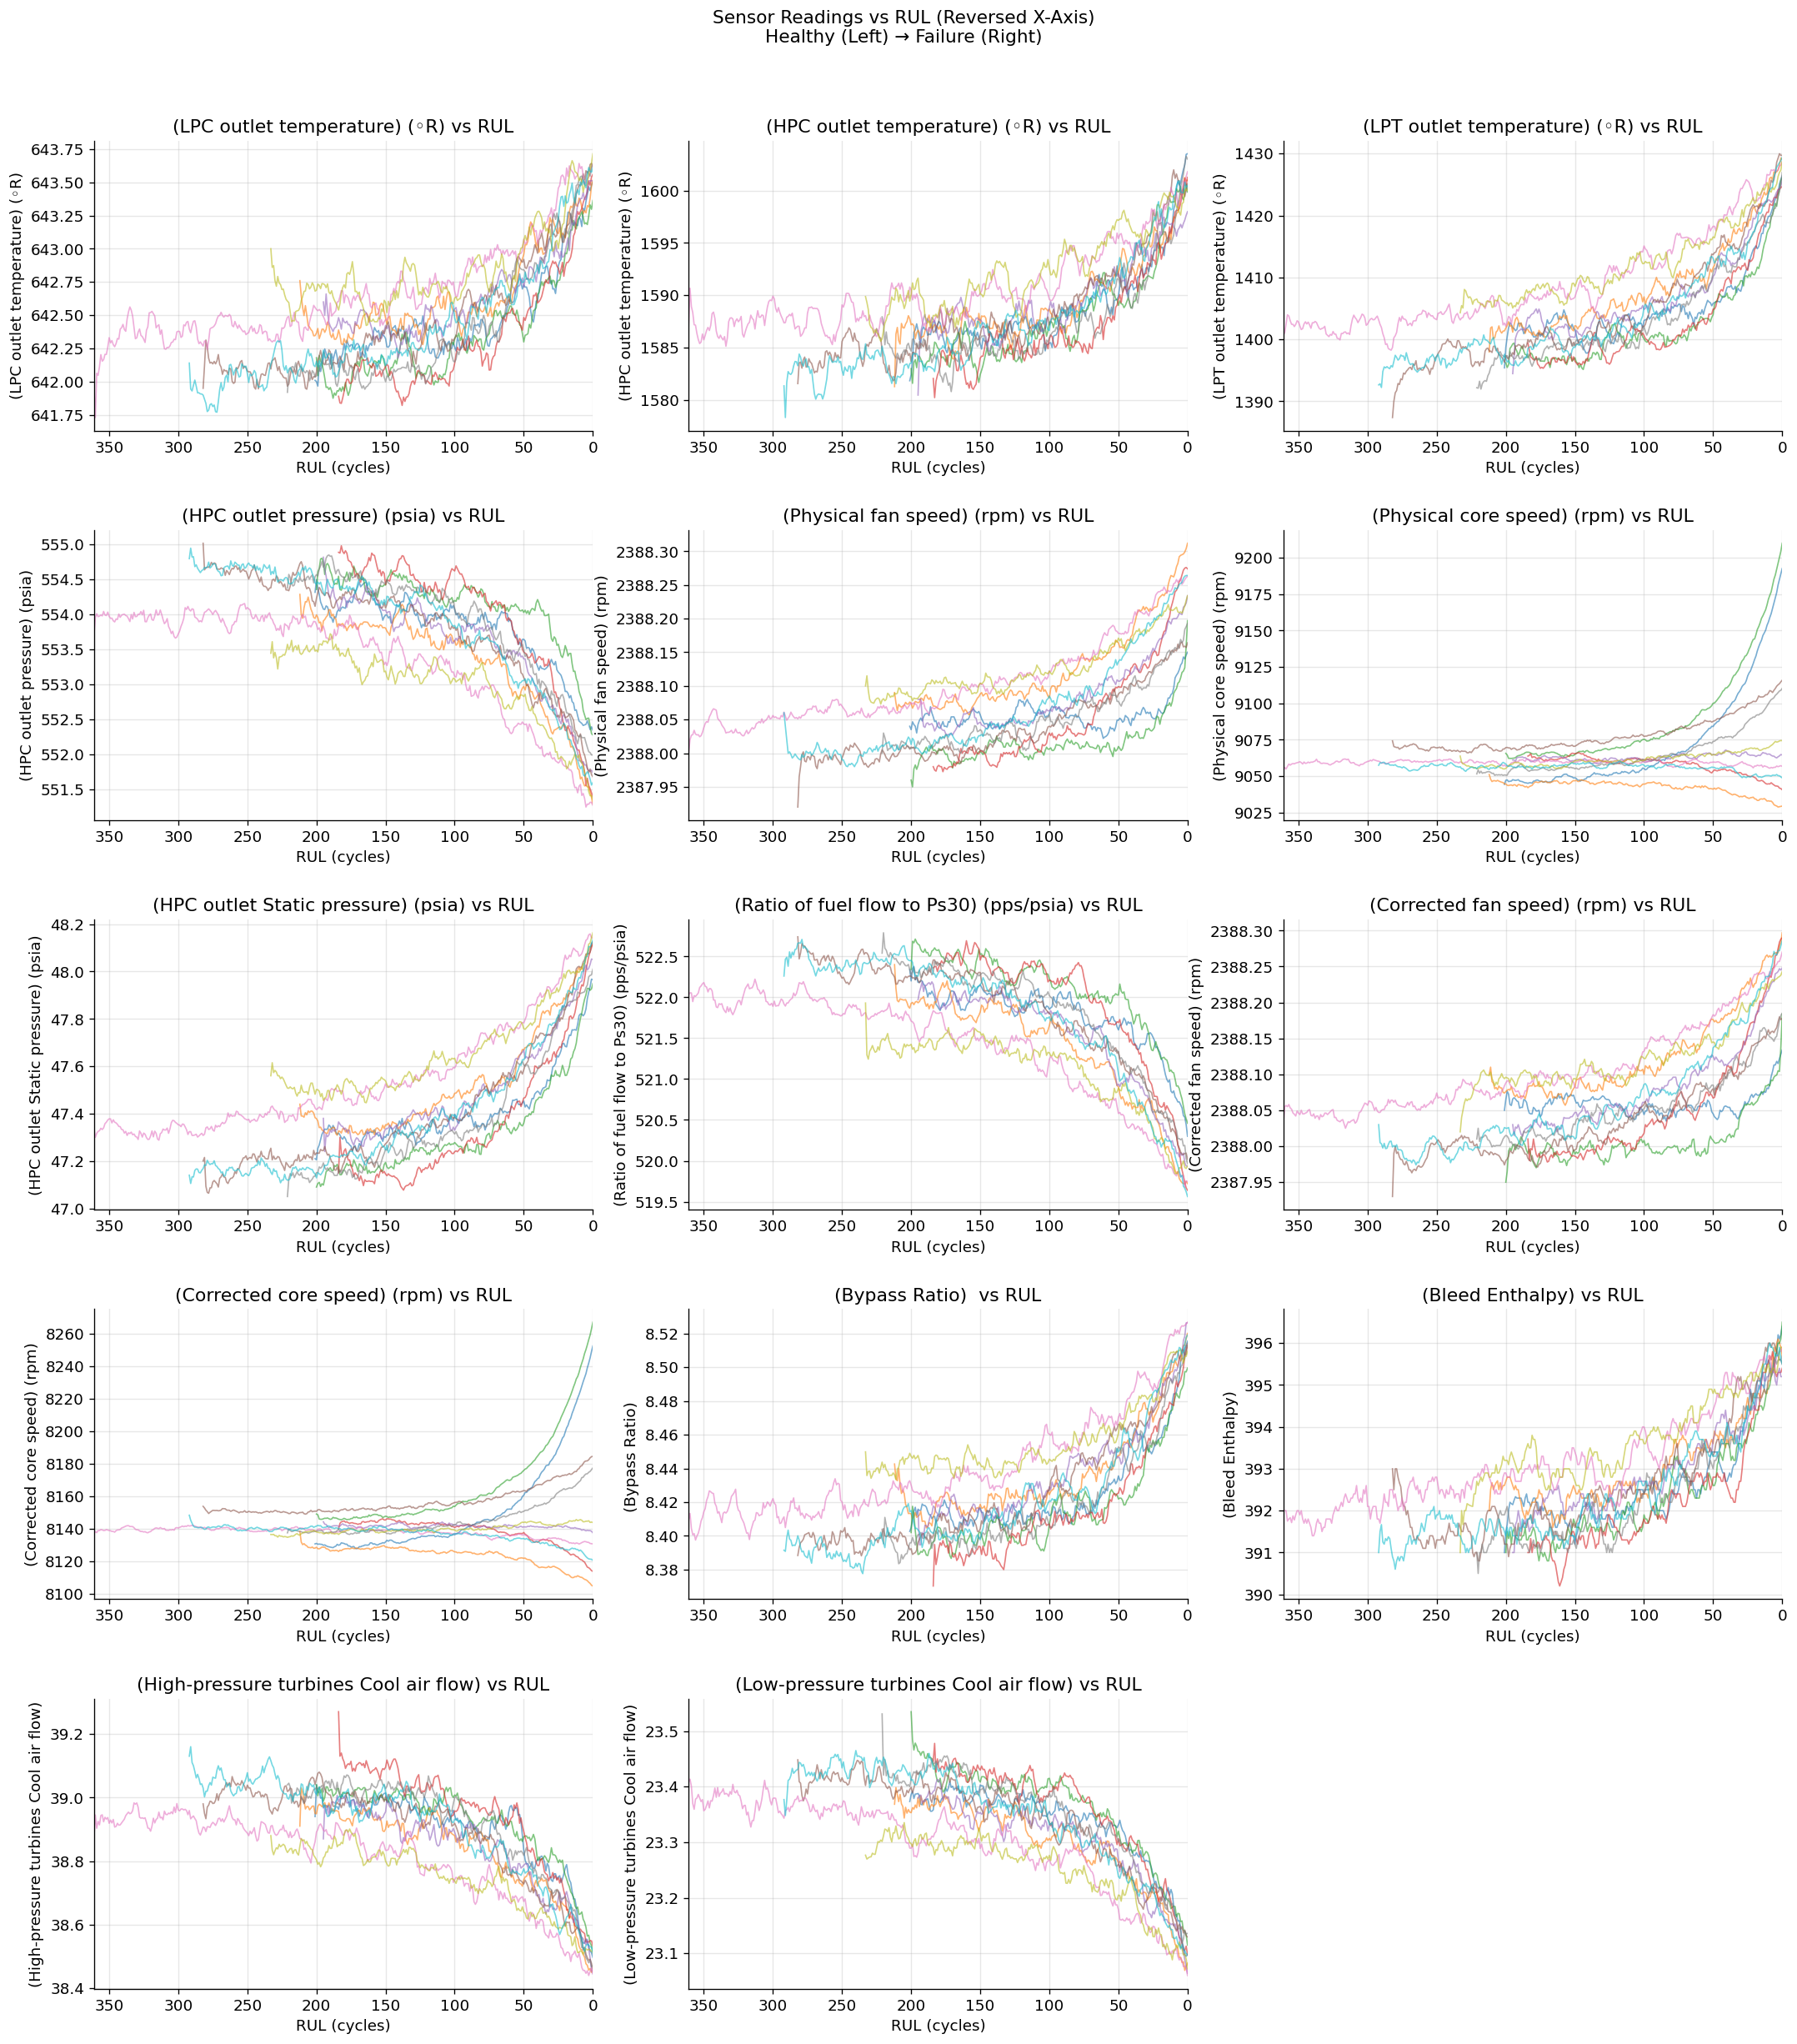

In [5]:
import matplotlib.pyplot as plt
import math
import numpy as np

def sensor_trends_analysis(df, sensor_cols, sensor_dict=None, n_engines=10, random_state=None):
    df_eda = df.copy()
    max_rul = df_eda['RUL'].max()
    
    n_sensors = len(sensor_cols)
    n_cols = 3
    n_rows = math.ceil(n_sensors / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    
    # Select random engines
    rng = np.random.default_rng(seed=random_state)
    engines = rng.choice(df_eda['unit_number'].unique(), size=n_engines, replace=False)
    
    for i, sensor in enumerate(sensor_cols):
        ax = axes[i]
        for unit in engines:
            subset = df_eda[df_eda['unit_number'] == unit].sort_values('time_cycles')
            smoothed = subset[sensor].rolling(window=10, min_periods=1).mean()
            ax.plot(subset['RUL'].values, smoothed.values, alpha=0.6, linewidth=1)
        
        ax.set_xlim(max_rul, 0)  # Reverse X-axis
        ax.set_xlabel('RUL (cycles)')
        y_label = sensor_dict.get(sensor, sensor) if sensor_dict else sensor
        ax.set_ylabel(y_label)
        ax.set_title(f'{y_label} vs RUL')
    
    # Remove empty subplots
    for j in range(n_sensors, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle('Sensor Readings vs RUL (Reversed X-Axis)\nHealthy (Left) → Failure (Right)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


# Usage example (plots random 10 engines, reproducible):
sensor_trends_analysis(df_train, sensor_cols, Sensor_dictionary, n_engines=10, random_state=42)

### Graph Analysis: Sensor Trends vs RUL

- The reversed x-axis highlights degradation progression clearly: curves are generally flatter at high RUL and become steeper near low RUL, indicating accelerated behavior close to failure.
- Clear upward trends (sensor value rises as failure approaches) are visible for: `s_2` (LPC outlet temperature), `s_3` (HPC outlet temperature), `s_4` (LPT outlet temperature), `s_8` (Physical fan speed), `s_11` (HPC outlet static pressure), `s_13` (Corrected fan speed), `s_15` (Bypass ratio), and `s_17` (Bleed enthalpy).
- Clear downward trends (sensor value falls as failure approaches) are visible for: `s_7` (HPC outlet pressure), `s_12` (Ratio of fuel flow to Ps30), `s_20` (High-pressure turbines cool air flow), and `s_21` (Low-pressure turbines cool air flow).
- `s_9` (Physical core speed) and `s_14` (Corrected core speed) show high between-engine dispersion with sharper late-stage shifts, suggesting high-variance but potentially high-signal behavior.
- Most sensors show non-linear trajectories over RUL (slow early changes, faster late changes), so linear-only assumptions are likely insufficient.
- Feature implication: include trend-aware descriptors (rolling mean, local slope, and curvature) in addition to raw levels to capture late-stage acceleration.
- Modeling implication: temporal sequence models remain appropriate because prognostic signal is encoded in trajectory shape, not only pointwise sensor magnitude.

#### Suggested Actions
1. **Add rolling mean/std features** (windows 5, 10, 20) — smoothed views capture the local trend shape that distinguishes healthy from degrading states.
2. **Add first-difference (`diff`) features** — these directly quantify the rate of change per cycle and will spike during the late-stage acceleration visible in the plots.
3. **Add EWMA features** (span 5, 10) — exponentially weighted averages give more weight to recent readings and respond faster to late-stage trend changes than simple rolling means.
4. **Add lag features** (1, 2, 5 steps) — provide the model with short-term history at each timestep for non-sequential models (trees, linear).
5. **Keep `s_9` and `s_14` despite high variance** — their late-stage bursts carry prognostic information; do not clip aggressively.
6. **Preserve non-linearity awareness** — use models capable of non-linear mapping (gradient-boosted trees, neural networks), and include polynomial or interaction terms only if a linear baseline is used.

📊 Sensor Outlier Summary:
s_2: 128 outliers (0.62%) → Low outlier presence
s_3: 165 outliers (0.80%) → Low outlier presence
s_4: 120 outliers (0.58%) → Low outlier presence
s_7: 110 outliers (0.53%) → Low outlier presence
s_8: 320 outliers (1.55%) → Moderate outlier presence
s_9: 1686 outliers (8.17%) → High outlier presence
s_11: 167 outliers (0.81%) → Low outlier presence
s_12: 146 outliers (0.71%) → Low outlier presence
s_13: 161 outliers (0.78%) → Low outlier presence
s_14: 1543 outliers (7.48%) → High outlier presence
s_15: 120 outliers (0.58%) → Low outlier presence
s_17: 81 outliers (0.39%) → Low outlier presence
s_20: 117 outliers (0.57%) → Low outlier presence
s_21: 136 outliers (0.66%) → Low outlier presence


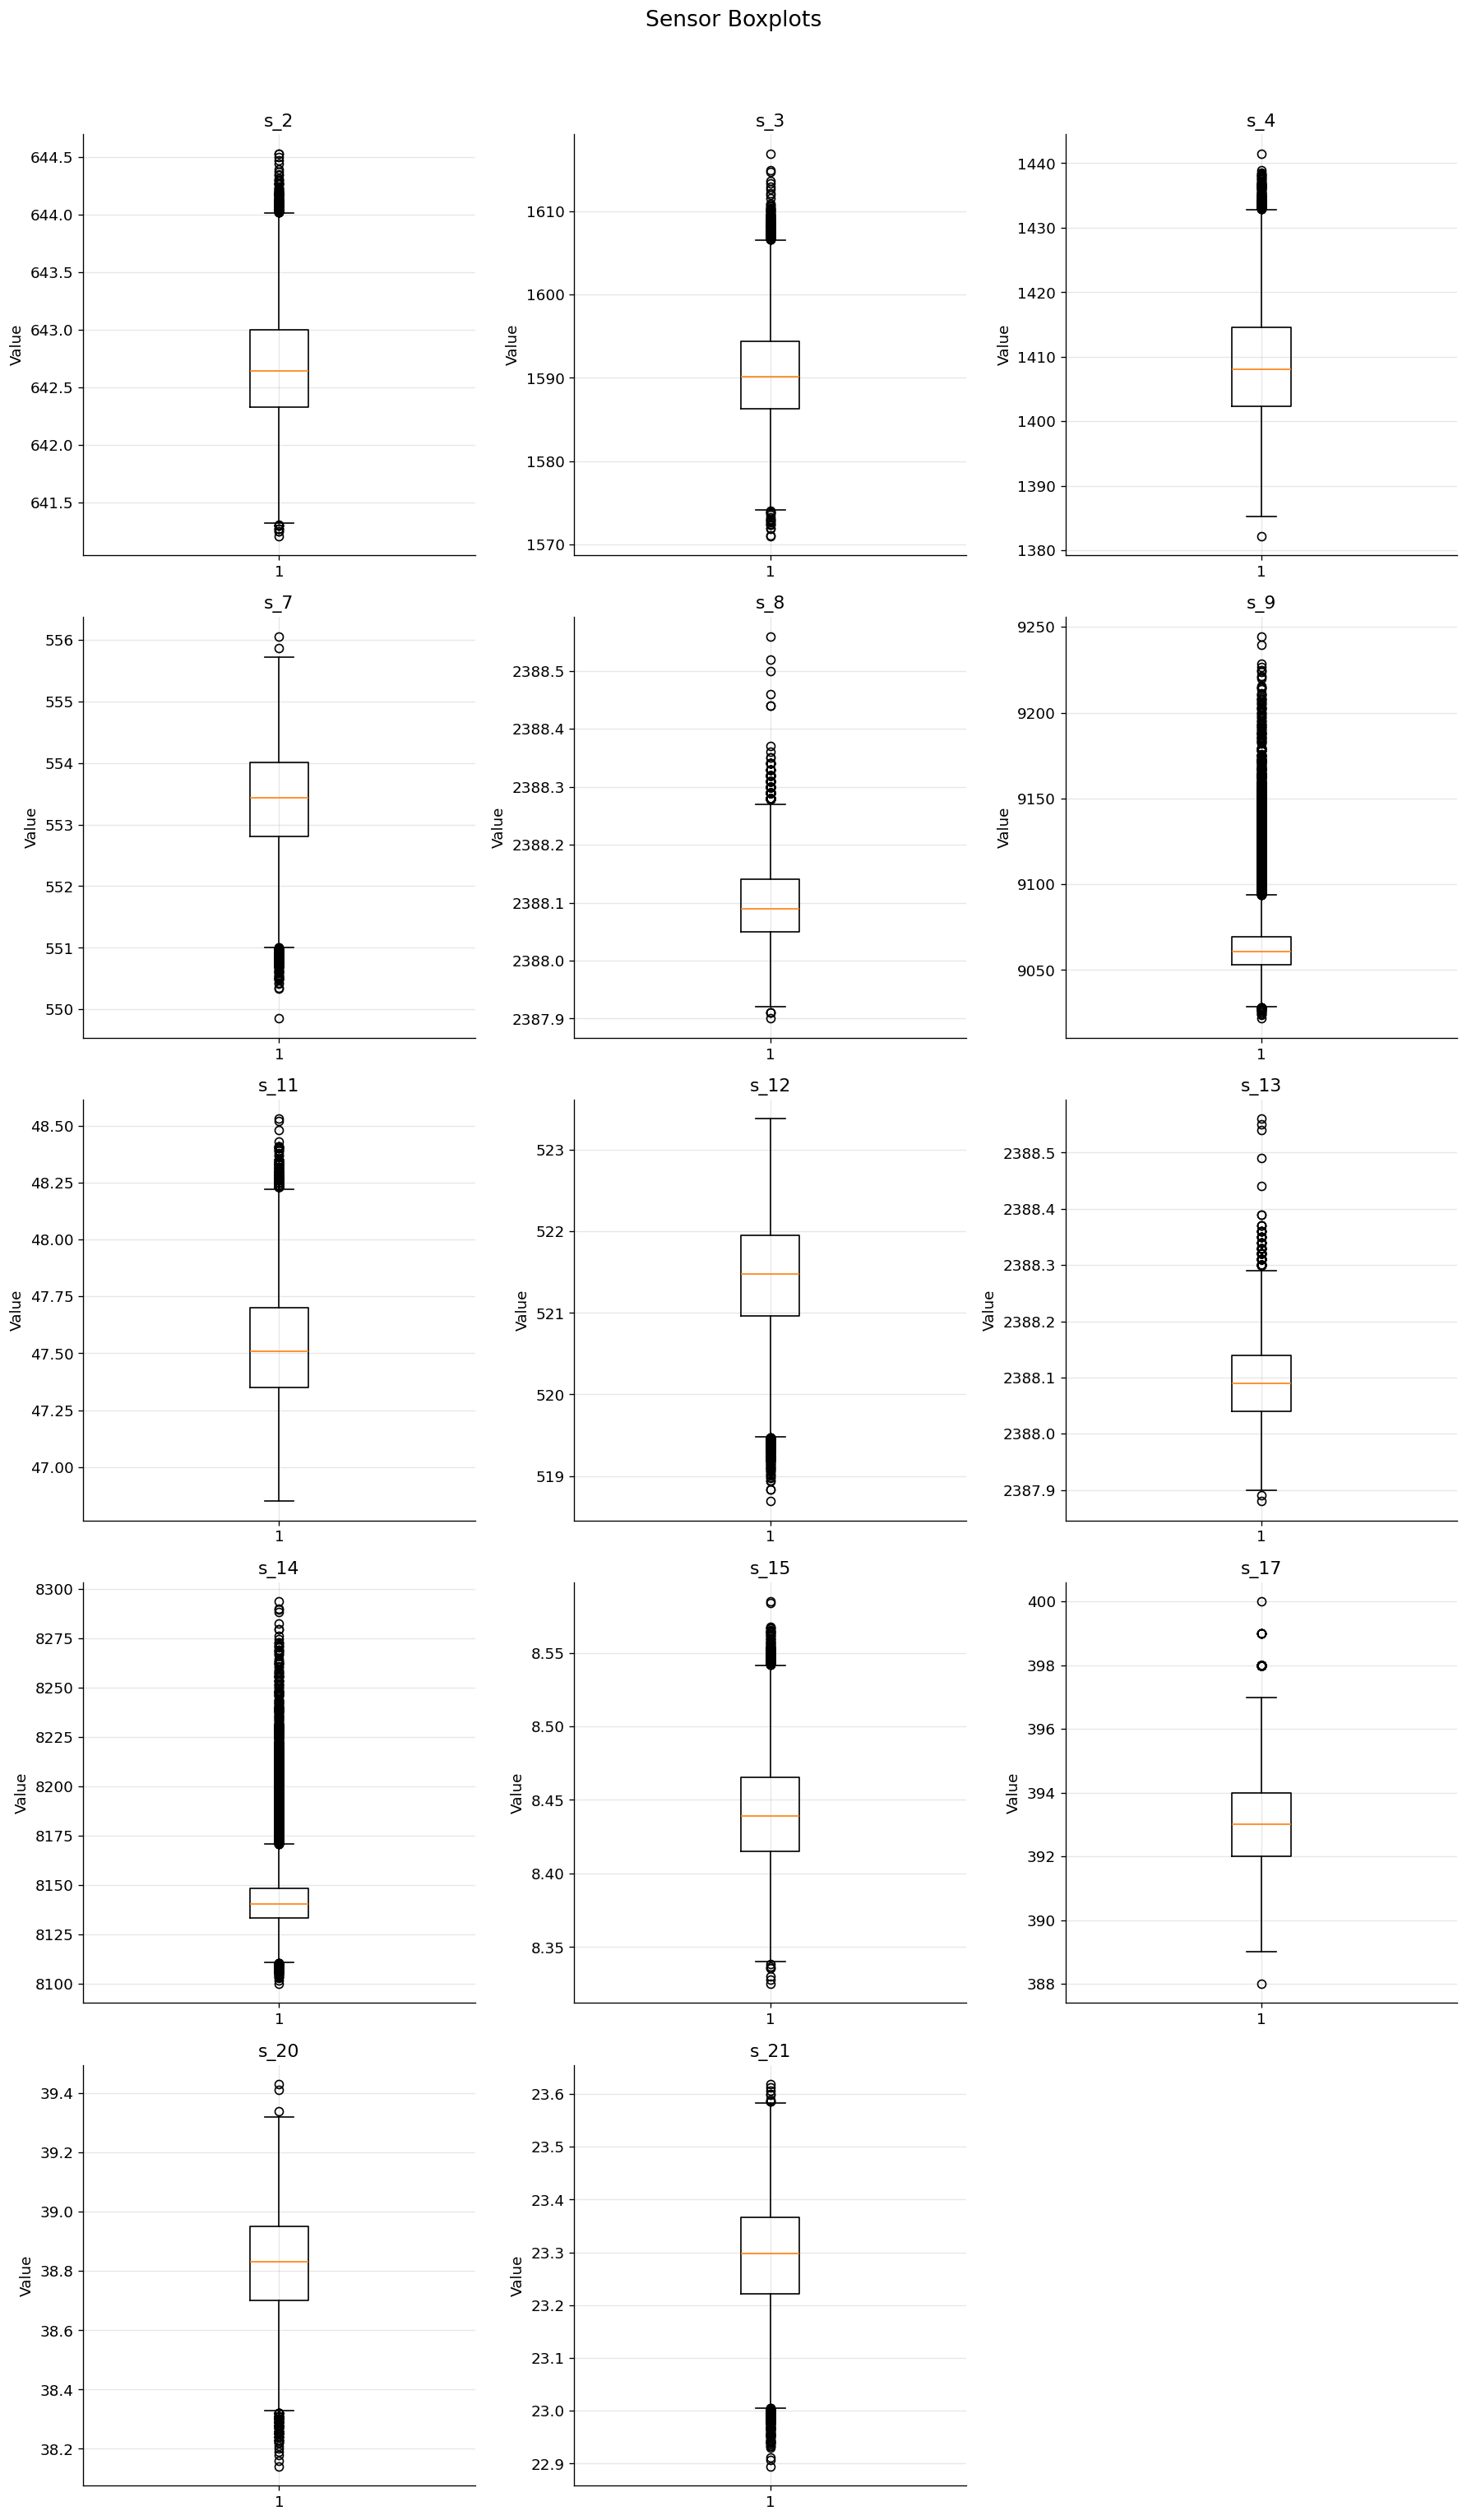

In [6]:
def boxplot_sensors_grid(df, sensor_names, n_cols=3):
    """
    Plot boxplots for multiple sensors in a grid and give textual outlier summary.
    
    Args:
        df: DataFrame containing the sensor columns.
        sensor_names: List of sensor column names (e.g., ['s_1', 's_2', ...]).
        n_cols: Number of columns in the grid.
    """
    # Keep only sensors that exist in df
    sensor_names = [s for s in sensor_names if s in df.columns]

    n_sensors = len(sensor_names)
    n_rows = (n_sensors + n_cols - 1) // n_cols  # ceil division for rows

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
    axes = axes.flatten()  # flatten for easy iteration

    print("📊 Sensor Outlier Summary:")
    for i, sensor in enumerate(sensor_names):
        # Boxplot
        axes[i].boxplot(df[sensor])
        axes[i].set_title(sensor)
        axes[i].set_ylabel('Value')

        # Outlier detection using IQR
        Q1 = df[sensor].quantile(0.25)
        Q3 = df[sensor].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[sensor] < Q1 - 1.5*IQR) | (df[sensor] > Q3 + 1.5*IQR)][sensor]
        n_outliers = len(outliers)
        perc_outliers = n_outliers / len(df) * 100

        # Decide seriousness
        if perc_outliers < 1:
            severity = "Low"
        elif perc_outliers < 5:
            severity = "Moderate"
        else:
            severity = "High"

        print(f"{sensor}: {n_outliers} outliers ({perc_outliers:.2f}%) → {severity} outlier presence")

    # Remove any extra subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle('Sensor Boxplots', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


# Generate sensor_names from remaining columns
sensor_names = [c for c in df_train.columns if c.startswith('s_')]

# Call the function
boxplot_sensors_grid(df_train, sensor_names)


#### Sensor Outlier Analysis

The trend plots and sensor distributions indicate that outlier behavior is not uniformly "noise"; some extremes occur near failure and can encode real degradation dynamics.

**High outlier sensors:**
- `s_9` → **8.17%** outliers
- `s_14` → **7.48%** outliers

Interpretation: these two sensors have strong dispersion and abrupt late-stage changes, so aggressive clipping can remove failure-relevant signal.

**Moderate outlier sensors:**
- `s_8` → **1.55%**

**Low outlier sensors:**
- Remaining selected sensors are generally **<1%** outliers.

**Recommended handling strategy:**
- Keep raw values for `s_9` and `s_14` for sequence models.
- Add robust-scaled variants (or winsorized copies) instead of replacing originals.
- Validate impact by ablation: raw only vs clipped only vs dual-representation features.

This approach preserves potentially predictive extremes while controlling instability during training.

#### Suggested Actions
1. **Winsorize at 1st–99th percentile** as the primary outlier strategy — this gently compresses tails without destroying the late-stage signal from `s_9`/`s_14`.
2. **Prepare a second variant with no outlier treatment** for deep learning models — LSTMs and Transformers benefit from seeing the raw failure-region extremes.
3. **Do NOT use aggressive fixed capping or IQR-based removal** — the 8% "outliers" in `s_9`/`s_14` are physically valid near-failure readings, not measurement errors.
4. **Always fit outlier thresholds on training data only** and apply to validation to prevent data leakage.
5. **Pair outlier handling with MinMax scaling** for neural network variants to keep activations well-conditioned.

### 3.3 Diagnostic: Correlation Analysis
Check for multicollinearity. If two sensors are highly correlated, they carry redundant information.

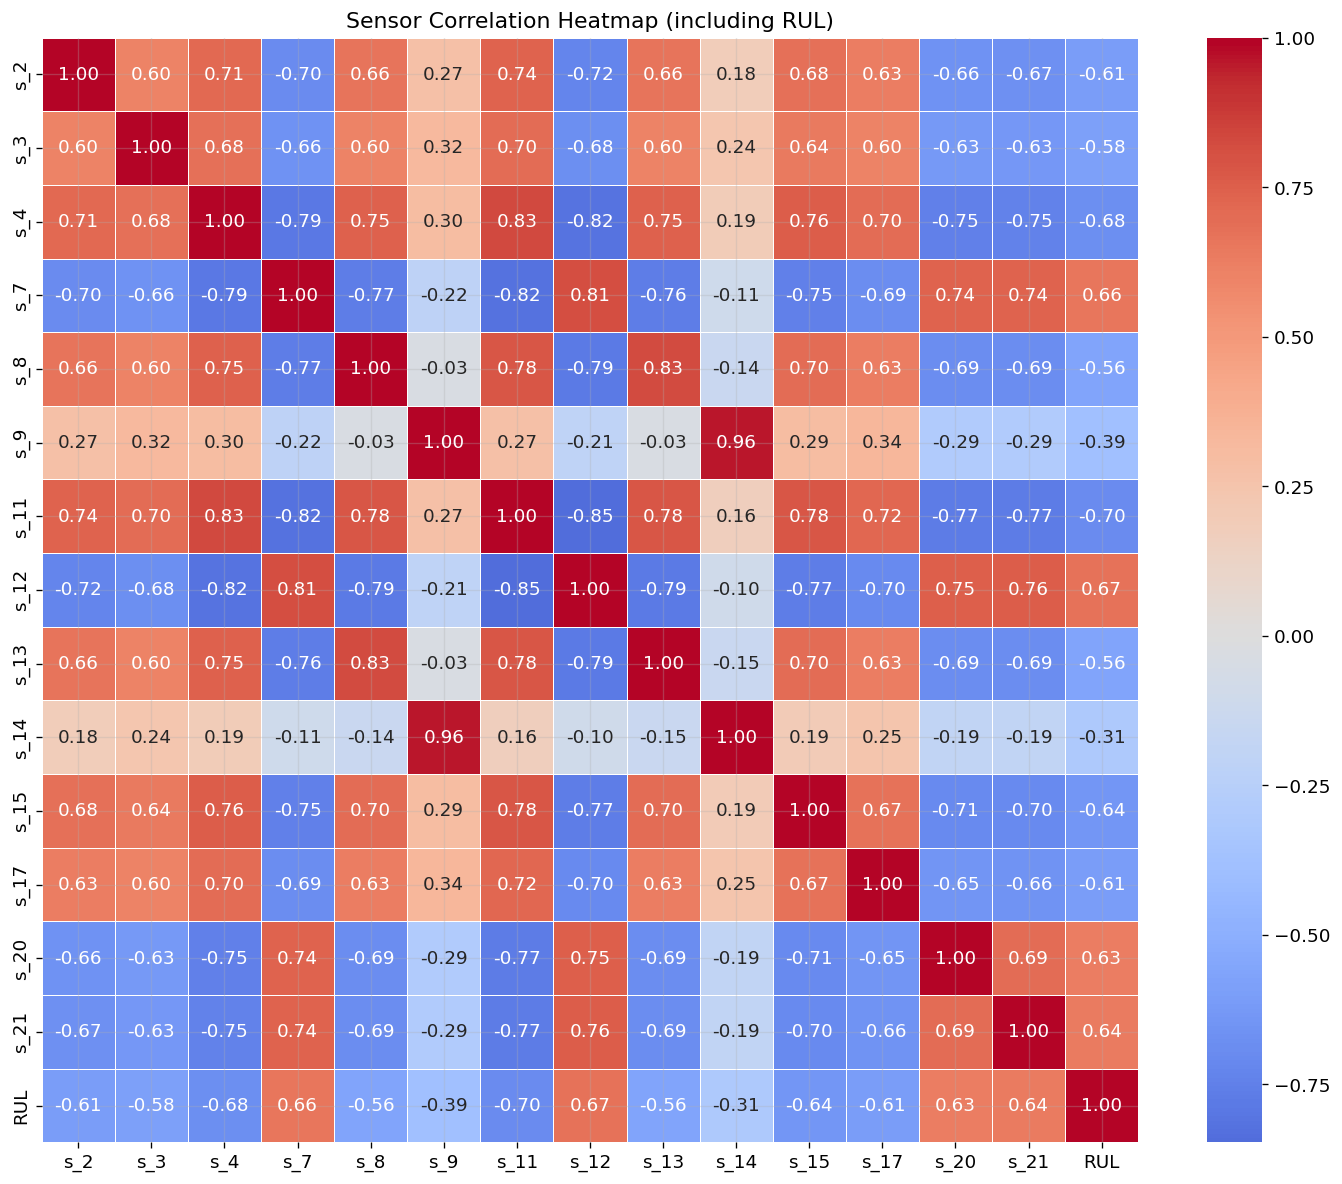

--- Top Correlations with RUL ---
s_11   -0.696228
s_4    -0.678948
s_15   -0.642667
s_2    -0.606484
s_17   -0.606154
s_3    -0.584520
s_8    -0.563968
s_13   -0.562569
s_9    -0.390102
s_14   -0.306769
s_20    0.629428
s_21    0.635662
s_7     0.657223
s_12    0.671983
RUL     1.000000
Name: RUL, dtype: float64


In [7]:
def correlation_analysis(df, sensor_cols):
    """Analyze sensor correlations."""
    rul_temp = df.groupby('unit_number')['time_cycles'].max().reset_index()
    rul_temp.columns = ['unit_number', 'max_cycle']
    df_eda = df.merge(rul_temp, on='unit_number')
    df_eda['RUL'] = df_eda['max_cycle'] - df_eda['time_cycles']
    
    corr = df_eda[sensor_cols + ['RUL']].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
    plt.title('Sensor Correlation Heatmap (including RUL)')
    plt.tight_layout()
    plt.show()
    
    return corr['RUL'].sort_values()

rul_corr = correlation_analysis(df_train, sensor_cols)
print("--- Top Correlations with RUL ---")
print(rul_corr)

### Graph Analysis: Correlation Heatmap

- The selected sensors form strong correlated blocks, indicating shared degradation modes and non-trivial redundancy.
- Strongest pairwise sensor relationship: `s_9` ↔ `s_14` at approximately **0.96**, suggesting near-duplicate information for some patterns.
- `RUL` has strongest negative associations with `s_11` (**-0.70**) and `s_4` (**-0.68**), meaning these sensors increase as failure approaches (RUL decreases).
- `RUL` has strongest positive associations with `s_12` (**+0.67**), `s_7` (**+0.66**), `s_21` (**+0.64**), and `s_20` (**+0.63**), meaning these tend to decrease toward failure.
- Mid-strength links (`|corr| ~ 0.56–0.64`) across several sensors show that signal is distributed, not concentrated in one feature.
- Modeling implication: feature selection should preserve both positively and negatively correlated groups to avoid directional bias.
- Regularization or dimensionality reduction is justified to reduce multicollinearity-driven instability in linear or tree-based baselines.

#### Suggested Actions
1. **Keep both `s_9` and `s_14` for now** — despite 0.96 correlation, their high-variance late-stage behavior may still contribute unique signal in non-linear models. Let model-based feature importance arbitrate.
2. **Build a PCA-based health index** from the full sensor space — the strong correlated block structure means PC1 will be a powerful composite degradation indicator.
3. **Include sensors from both correlation directions** (positive and negative with RUL) — top candidates: `s_11`, `s_4`, `s_12`, `s_7`, `s_21`, `s_20`, `s_2`, `s_3`.
4. **Apply PCA dimensionality reduction** as an optional dataset variant — given the redundancy, 5 PCs (~87% variance) can replace 14 raw sensors for compact model pipelines.
5. **Use regularization** (L1/L2) or tree-based ensembles rather than raw OLS to handle collinearity in flat-feature models.

**Reasoning for Next Step:** The heatmap confirms high multicollinearity (many pairs with large |correlation|), so PCA/feature-compression is appropriate to reduce redundancy while retaining the dominant degradation structure. We therefore use PCA as a diagnostic to quantify how much information can be preserved with fewer components.

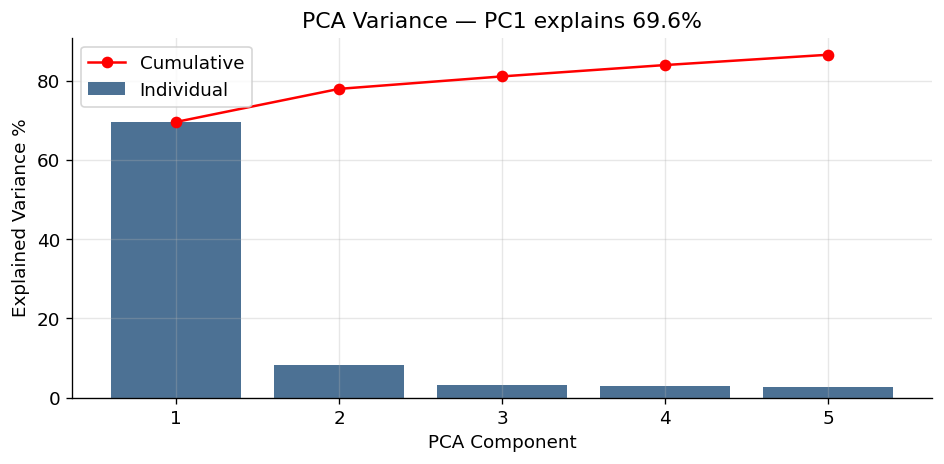

In [8]:
def pca_analysis(df, sensor_cols):
    """Perform PCA to assess global variance."""
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(df[sensor_cols])
    
    pca = PCA(n_components=5)
    pca.fit(X_scaled)
    
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    
    plt.figure(figsize=(8, 4))
    plt.bar(range(1, 6), explained_variance * 100, color=COLORS[0], alpha=0.8, label='Individual')
    plt.plot(range(1, 6), cumulative_variance * 100, 'r-o', label='Cumulative')
    plt.xlabel('PCA Component')
    plt.ylabel('Explained Variance %')
    plt.title(f'PCA Variance — PC1 explains {explained_variance[0]*100:.1f}%')
    plt.legend()
    plt.tight_layout()
    plt.show()

pca_analysis(df_train, sensor_cols)

### Graph Analysis: PCA Explained Variance

- **PC1 explains 69.6%** of total variance, indicating one dominant latent degradation direction shared by many sensors.
- Cumulative variance rises to roughly **78%** with 2 components and about **87%** with 5 components.
- The large PC1-to-PC2 drop shows diminishing returns after the first component; later PCs add finer, secondary behavior.
- This aligns with the correlation heatmap: sensors move in coordinated blocks, so much structure is compressible.
- Practical takeaway for baselines: low-dimensional representations (e.g., 3–5 PCs) can retain most global information with lower noise sensitivity.
- Practical takeaway for deep sequence models: raw sensors remain useful, but PCA features can be added as auxiliary channels for stabilization and faster convergence.

#### Suggested Actions
1. **Create a "PCA-compact" dataset variant** retaining 95% variance (~7-8 components) — suitable for linear models, SVR, and lightweight tree baselines.
2. **Add PC1 as a `health_index` feature** to the full-sensor datasets — it acts as a single-number degradation summary and is strongly predictive on its own.
3. **Do NOT apply PCA to deep learning datasets** — LSTMs/Transformers learn their own internal representations; PCA pre-compression removes potentially useful fine-grained sensor interactions.
4. **Fit PCA on training data only** and transform validation with the same projection to prevent leakage.
5. **Consider PCA on engineered features** (after rolling/lag/diff creation) as a second reduction stage for very high-dimensional experiment variants (300+ features).

### Summary of EDA-Driven Decisions for Feature Engineering

Based on the analysis above, the following **dataset preparation strategies** will be implemented in notebook `04_feature_engineering`:

| Dataset | Outlier Handling | Feature Engineering | Scaling | PCA | Target Use Case |
|---------|-----------------|---------------------|---------|-----|-----------------|
| **DS-A** (Baseline) | None | Raw sensors + clipped RUL | MinMax | None | Baseline for all models |
| **DS-B** (Classical ML) | Winsorize 1-99% | Lag + Rolling + Diff + EWMA + Health Index | MinMax | None | Tree-based / ensemble models |
| **DS-C** (Compact ML) | Winsorize 1-99% | Lag + Rolling + Diff + EWMA | MinMax | 95% variance | Linear / regularized models |
| **DS-D** (Deep Learning) | None (preserve extremes) | Rolling + Diff + Health Index | MinMax | None | LSTM / Transformer |
| **DS-E** (Full + Robust) | Clip 1-99% + MinMax | Lag + Rolling + Diff + EWMA + Health Index | Included | None | Comprehensive ensemble |

These choices are grounded in the specific findings from this EDA — the non-linear degradation trajectories, the physically meaningful outliers in `s_9`/`s_14`, the strong correlated sensor blocks, and the dominant PC1 variance structure.